# probability_reliability_correction 官方样例验证

本 Notebook 对照三类结果：

1. **修改后方法**：meb 六维网格 → 插件 / `prb_*` CLI `process`
2. **原方法**：Iris Cube → Improver 插件 / `improver *-reliability-*` CLI
3. **KGO**：官方预期输出

数值摘要统一给出三组差值：

- 修改后 ~ KGO
- 原方法 ~ KGO
- **修改后 ~ 原方法**

流程：

1. 运行（或确认已运行）`probability_reliability_correction/cli/preprocess_test_data.py`，生成各用例 `cli_input/`
2. Notebook **只读取** `cli_input/`（修改后）与用例目录下的 Iris 源/KGO（原方法）
3. 做上述三方差值摘要与作图对比
4. **CLI 示例**：修改后 `prb_*.process(cli_input)` vs 原版 `improver` 命令 vs KGO

覆盖插件：`Construct` / `Aggregate` / `Manipulate` / `Apply`（取 basic 子路径）。


## 1. 环境准备

In [1]:
%matplotlib inline

from __future__ import annotations

import sys
import warnings
from pathlib import Path

import iris
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
IMPROVER_ROOT = PROJECT_ROOT / "improver-1.18.7"
DATA_DIR = PACKAGE_ROOT / "test_data"

for path in (str(PROJECT_ROOT), str(IMPROVER_ROOT)):
    if path not in sys.path:
        sys.path.insert(0, path)

from improver import cli as improver_cli  # pyright: ignore[reportMissingImports]
from improver.calibration.reliability_calibration import (  # pyright: ignore[reportMissingImports]
    AggregateReliabilityCalibrationTables as OrigAggregate,
    ApplyReliabilityCalibration as OrigApply,
    ConstructReliabilityCalibrationTables as OrigConstruct,
    ManipulateReliabilityTable as OrigManipulate,
)
from probability_reliability_correction import (
    AggregateReliabilityCalibrationTables,
    ApplyReliabilityCalibration,
    ConstructReliabilityCalibrationTables,
    ManipulateReliabilityTable,
)
from probability_reliability_correction.cli.prb_aggregate_reliability_tables import (
    process as aggregate_cli_process,
)
from probability_reliability_correction.cli.prb_apply_reliability_calibration import (
    process as apply_cli_process,
)
from probability_reliability_correction.cli.prb_construct_reliability_tables import (
    process as construct_cli_process,
)
from probability_reliability_correction.cli.prb_manipulate_reliability_table import (
    process as manipulate_cli_process,
)
from probability_reliability_correction.src.utils._reliability import TABLE_ROW_NAMES


print("PACKAGE_ROOT =", PACKAGE_ROOT)
print("DATA_DIR =", DATA_DIR)


PACKAGE_ROOT = D:\workspace\improver\probability_reliability_correction
DATA_DIR = D:\workspace\improver\probability_reliability_correction\test_data


## 2. 对照工具

用于数值摘要、坐标转换与作图。**Iris→meb 预处理见 `cli/preprocess_test_data.py`**。

差值打印约定：每个用例依次输出「修改后~KGO / 原方法~KGO / 修改后~原方法」。Manipulate 多阈值结果汇总为一行，避免刷屏。


In [2]:
def _find_threshold_coord(cube):
    for coord in cube.coords():
        if "spp__relative_to_threshold" in coord.attributes:
            return coord
    raise ValueError(f"未找到阈值坐标: {cube.name()}")


def meb_table_to_iris_layout(ds: xr.Dataset) -> np.ndarray:
    """meb 表 → 原布局 (level, 3, n_bin[, lat, lon])。"""
    obs = ds["observation_count"].values[:, :, 0, 0, ...]
    psum = ds["sum_of_forecast_probabilities"].values[:, :, 0, 0, ...]
    fcnt = ds["forecast_count"].values[:, :, 0, 0, ...]
    stacked = np.stack([obs, psum, fcnt], axis=0)
    return np.moveaxis(stacked, 2, 0)


def iris_table_data(cube) -> np.ndarray:
    return np.ma.filled(np.ma.asarray(cube.data), 0).astype(np.float32)


def plot_triple_fields(migrated, original, kgo, title: str, *, cmap="viridis"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
    for ax, arr, lab in zip(
        axes, (migrated, original, kgo), ("修改后", "原方法", "KGO")
    ):
        im = ax.imshow(np.asarray(arr, dtype=float), origin="lower", cmap=cmap)
        ax.set_title(lab)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


def plot_reliability_diagrams(mig_arr, orig_arr, kgo_arr, title: str):
    mig_arr = np.asarray(mig_arr)
    orig_arr = np.asarray(orig_arr)
    kgo_arr = np.asarray(kgo_arr)
    n_thr = kgo_arr.shape[0]
    fig, axes = plt.subplots(1, n_thr, figsize=(4.2 * n_thr, 3.8), squeeze=False)

    def _curve(arr):
        # arr: (n_thr, 3, n_bin, ...) → 平均预报概率 / 观测频率
        arr = np.asarray(arr, dtype=np.float64)
        while arr.ndim > 3:
            arr = arr.mean(axis=-1)
        obs, psum, fcnt = arr[:, 0], arr[:, 1], arr[:, 2]
        with np.errstate(invalid="ignore", divide="ignore"):
            xp = np.where(fcnt > 0, psum / fcnt, np.nan)
            yp = np.where(fcnt > 0, obs / fcnt, np.nan)
        return xp, yp

    for ithr in range(n_thr):
        ax = axes[0, ithr]
        n_bin = int(np.asarray(kgo_arr[ithr : ithr + 1]).shape[-1])
        for arr, lab, style in (
            (mig_arr, "修改后", "o-"),
            (orig_arr, "原方法", "s--"),
            (kgo_arr, "KGO", "^:"),
        ):
            xp, yp = _curve(arr[ithr : ithr + 1])
            ms = 10 if n_bin <= 2 else 5
            ax.plot(xp[0], yp[0], style, label=lab, markersize=ms, alpha=0.9)
        ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlabel("平均预报概率")
        ax.set_ylabel("观测频率")
        ax.set_title(f"threshold[{ithr}]  (n_bin={n_bin})")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        if n_bin <= 1:
            ax.text(
                0.05,
                0.15,
                "仅 1 个有效箱，\n曲线退化为单点",
                transform=ax.transAxes,
                fontsize=9,
                color="0.35",
            )
    fig.suptitle(title)
    plt.show()


def ensure_path_removed(path: Path) -> None:
    path = Path(path)
    if path.is_file():
        path.unlink()
    elif path.is_dir():
        for p in path.glob("*"):
            if p.is_file():
                p.unlink()


def patch_orig_manipulate_for_iris() -> None:
    """Iris 3.x：新建 probability_bin 时保留 var_name，供原版 Manipulate 方法使用。"""

    def _create_new_bin_coord_iris_compat(probability_bin_coord, upper: int):
        old_bounds = probability_bin_coord.bounds
        new_bounds = np.concatenate(
            (
                old_bounds[0 : upper - 1],
                np.array([[old_bounds[upper - 1, 0], old_bounds[upper, 1]]]),
                old_bounds[upper + 1 :],
            )
        )
        new_points = np.mean(new_bounds, axis=1, dtype=np.float32)
        return iris.coords.DimCoord(
            new_points,
            long_name=probability_bin_coord.long_name or "probability_bin",
            var_name=probability_bin_coord.var_name,
            units=probability_bin_coord.units,
            bounds=new_bounds,
            attributes=dict(probability_bin_coord.attributes),
        )

    OrigManipulate._create_new_bin_coord = staticmethod(
        _create_new_bin_coord_iris_compat
    )


def summarize_diff(name: str, a: np.ndarray, b: np.ndarray) -> dict:
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if a.shape != b.shape:
        print(f"{name}: shape 不一致 {a.shape} vs {b.shape}")
        return {"name": name, "shape_mismatch": True}
    diff = a - b
    out = {
        "name": name,
        "allclose": bool(np.allclose(a, b, equal_nan=True)),
        "maxabs": float(np.nanmax(np.abs(diff))) if diff.size else 0.0,
        "meanabs": float(np.nanmean(np.abs(diff))) if diff.size else 0.0,
    }
    print(
        f"{name}: allclose={out['allclose']} maxabs={out['maxabs']} meanabs={out['meanabs']}"
    )
    return out


def summarize_triple(name: str, mig, orig, kgo) -> None:
    """打印修改后/原方法/KGO 三方差值。"""
    summarize_diff(f"{name}: 修改后 ~ KGO", mig, kgo)
    summarize_diff(f"{name}: 原方法 ~ KGO", orig, kgo)
    summarize_diff(f"{name}: 修改后 ~ 原方法", mig, orig)


def summarize_level_maps(name: str, mig_map: dict, orig_map: dict, kgo_map: dict) -> None:
    """多阈值 map 汇总三方差值（不逐阈打印）。"""
    levels = sorted(kgo_map)
    n = len(levels)
    if n == 0:
        print(f"{name}: 无阈值可比")
        return

    def _stats(a, b):
        a = np.asarray(a, dtype=np.float64)
        b = np.asarray(b, dtype=np.float64)
        if a.shape != b.shape:
            return None, True
        d = np.abs(a - b)
        return float(np.nanmax(d)) if d.size else 0.0, False

    pairs = [
        ("修改后 ~ KGO", mig_map, kgo_map),
        ("原方法 ~ KGO", orig_map, kgo_map),
        ("修改后 ~ 原方法", mig_map, orig_map),
    ]
    for label, left, right in pairs:
        if not right:
            print(f"{name}: {label}: 右侧结果缺失，跳过")
            continue
        ok = 0
        maxabs_all = 0.0
        shape_bad = 0
        missing = 0
        for lev in levels:
            if lev not in left or lev not in right:
                missing += 1
                continue
            mx, bad = _stats(left[lev], right[lev])
            if bad:
                shape_bad += 1
                continue
            maxabs_all = max(maxabs_all, mx)
            if mx == 0.0 and np.array_equal(
                np.asarray(left[lev]), np.asarray(right[lev])
            ):
                ok += 1
            elif np.allclose(left[lev], right[lev], equal_nan=True):
                ok += 1
        print(
            f"{name}: {label}: 一致 {ok}/{n}, max(maxabs)={maxabs_all}, "
            f"缺侧={missing}, shape不一致={shape_bad}"
        )
    print(f"{name}: 阈值数={n}, 各阈值箱数=" + str({lev: kgo_map[lev].shape[-1] for lev in levels}))



def reliability_tables_to_map(items, *, from_meb: bool) -> dict:
    """将 Manipulate 输出的多阈值表列表转为 {level: (3, n_bin)}。"""
    out = {}
    for item in items:
        if from_meb:
            lev = float(np.asarray(item["level"].values).reshape(-1)[0])
            arr = np.stack(
                [
                    item["observation_count"].values.reshape(-1),
                    item["sum_of_forecast_probabilities"].values.reshape(-1),
                    item["forecast_count"].values.reshape(-1),
                ],
                axis=0,
            )
        else:
            thr = _find_threshold_coord(item)
            lev = float(thr.points[0])
            arr = iris_table_data(item)
        out[lev] = arr
    return out


print("对照工具已就绪；TABLE_ROW_NAMES =", TABLE_ROW_NAMES)


对照工具已就绪；TABLE_ROW_NAMES = ('observation_count', 'sum_of_forecast_probabilities', 'forecast_count')


## 3. ConstructReliabilityCalibrationTables

用例目录：`test_data/construct-reliability-tables/basic/`

### 3.1 输入读取


In [3]:
CONSTRUCT_DIR = DATA_DIR / "construct-reliability-tables" / "basic"
CONSTRUCT_CLI = CONSTRUCT_DIR / "cli_input"

fc_in = xr.open_dataarray(CONSTRUCT_CLI / "forecast.nc")
tr_in = xr.open_dataarray(CONSTRUCT_CLI / "truth.nc")
print("forecast", fc_in.dims, dict(fc_in.sizes))
print("truth   ", tr_in.dims, dict(tr_in.sizes))


forecast ('member', 'level', 'time', 'dtime', 'lat', 'lon') {'member': 1, 'level': 2, 'time': 2, 'dtime': 1, 'lat': 2, 'lon': 2}
truth    ('member', 'level', 'time', 'dtime', 'lat', 'lon') {'member': 1, 'level': 2, 'time': 2, 'dtime': 1, 'lat': 2, 'lon': 2}


### 3.2 插件方法调用

调用修改后插件方法和原方法。


In [4]:
# 修改后插件方法调用
mig_construct = ConstructReliabilityCalibrationTables().process(fc_in, tr_in)
mig_construct_agg = ConstructReliabilityCalibrationTables().process(
    fc_in, tr_in, aggregate_coords=["lat", "lon"]
)
mig_construct_sv = ConstructReliabilityCalibrationTables(
    n_probability_bins=5,
    single_value_lower_limit=True,
    single_value_upper_limit=True,
).process(fc_in, tr_in)

In [5]:
# 原方法：直接读用例目录下已拼接的多时效 Iris
orig_fc = iris.load_cube(str(CONSTRUCT_DIR / "forecast.nc"))
orig_tr = iris.load_cube(str(CONSTRUCT_DIR / "truth.nc"))
# 原方法调用
orig_construct = OrigConstruct().process(orig_fc, orig_tr)
orig_construct_agg = OrigConstruct().process(
    orig_fc, orig_tr, aggregate_coords=["latitude", "longitude"]
)
orig_construct_sv = OrigConstruct(
    n_probability_bins=5,
    single_value_lower_limit=True,
    single_value_upper_limit=True,
).process(orig_fc, orig_tr)

### 3.3 数值对比与绘图对比

建表（无单值端点箱）: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
建表（无单值端点箱）: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
建表（无单值端点箱）: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


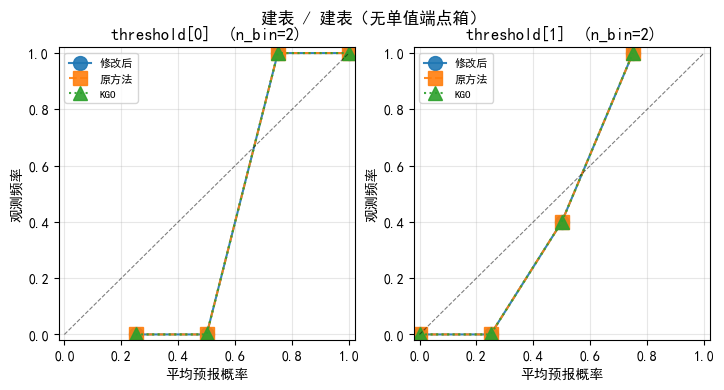

建表并空间聚合: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
建表并空间聚合: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
建表并空间聚合: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


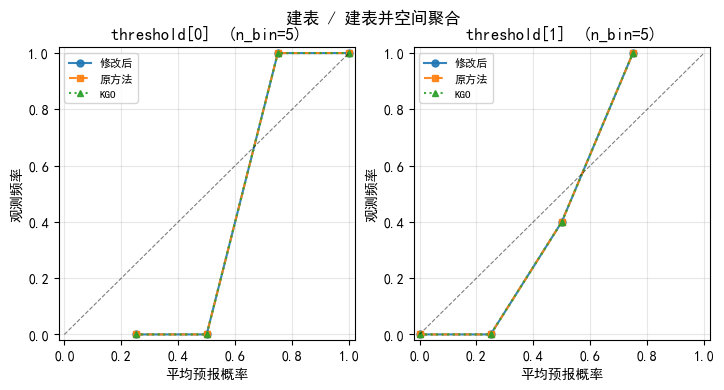

建表（含单值端点箱）: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
建表（含单值端点箱）: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
建表（含单值端点箱）: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


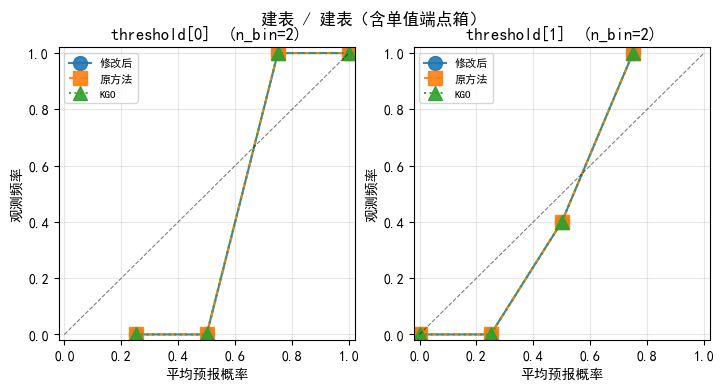

In [6]:
# 读取KGO结果
kgo_construct = iris.load_cube(str(CONSTRUCT_DIR / "kgo_without_single_value_bins.nc"))
kgo_construct_agg = iris.load_cube(str(CONSTRUCT_DIR / "kgo_aggregated.nc"))
kgo_construct_sv = iris.load_cube(str(CONSTRUCT_DIR / "kgo_single_value_bins.nc"))

cases = [
    ("建表（无单值端点箱）", meb_table_to_iris_layout(mig_construct), iris_table_data(orig_construct), iris_table_data(kgo_construct)),
    ("建表并空间聚合", meb_table_to_iris_layout(mig_construct_agg)[:, :, :, 0, 0], iris_table_data(orig_construct_agg), iris_table_data(kgo_construct_agg)),
    ("建表（含单值端点箱）", meb_table_to_iris_layout(mig_construct_sv), iris_table_data(orig_construct_sv), iris_table_data(kgo_construct_sv)),
]
for name, mig, orig, kgo in cases:
    summarize_triple(name, mig, orig, kgo)
    plot_reliability_diagrams(mig, orig, kgo, f"建表 / {name}")


## 4. AggregateReliabilityCalibrationTables

用例目录：`test_data/aggregate-reliability-tables/basic/`

### 4.1 输入读取


In [7]:
AGG_DIR = DATA_DIR / "aggregate-reliability-tables" / "basic"
AGG_CLI = AGG_DIR / "cli_input"

agg_t1_in = xr.open_dataset(AGG_CLI / "reliability_table.nc")
agg_t2_in = xr.open_dataset(AGG_CLI / "reliability_table_2.nc")
print("aggregate tables:", list(agg_t1_in.data_vars), list(agg_t2_in.data_vars))


aggregate tables: ['observation_count', 'sum_of_forecast_probabilities', 'forecast_count'] ['observation_count', 'sum_of_forecast_probabilities', 'forecast_count']


### 4.2 插件方法调用


In [8]:
# 修改后插件方法调用
mig_collapse = AggregateReliabilityCalibrationTables().process(
    [agg_t1_in], coordinates=["lat", "lon"]
)
mig_multi = AggregateReliabilityCalibrationTables().process([agg_t1_in, agg_t2_in])

In [9]:
orig_t1 = iris.load_cube(str(AGG_DIR / "reliability_table.nc"))
orig_t2 = iris.load_cube(str(AGG_DIR / "reliability_table_2.nc"))
# 原方法调用
orig_collapse = OrigAggregate().process([orig_t1], ["latitude", "longitude"])
orig_multi = OrigAggregate().process([orig_t1, orig_t2])

### 4.3 数值对比与绘图对比


聚合（折叠经纬）: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
聚合（折叠经纬）: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
聚合（折叠经纬）: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


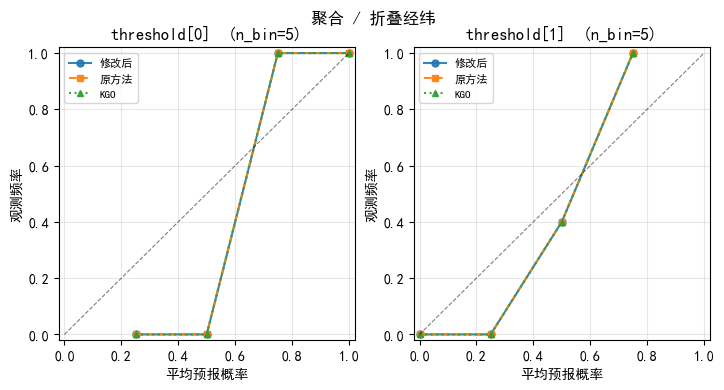

聚合（多表合并）: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
聚合（多表合并）: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
聚合（多表合并）: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


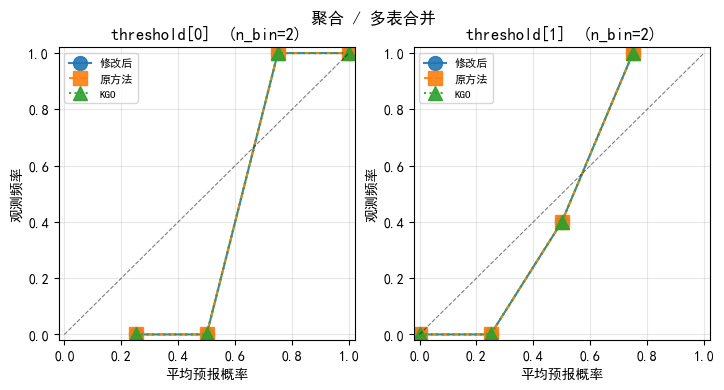

In [10]:
# 读取KGO结果
kgo_collapse = iris_table_data(iris.load_cube(str(AGG_DIR / "collapse_lat_lon_kgo.nc")))
kgo_multi = iris_table_data(iris.load_cube(str(AGG_DIR / "multiple_tables_kgo.nc")))

mig_c = meb_table_to_iris_layout(mig_collapse)[:, :, :, 0, 0]
mig_m = meb_table_to_iris_layout(mig_multi)
orig_c = iris_table_data(orig_collapse)
orig_m = iris_table_data(orig_multi)

summarize_triple("聚合（折叠经纬）", mig_c, orig_c, kgo_collapse)
plot_reliability_diagrams(mig_c, orig_c, kgo_collapse, "聚合 / 折叠经纬")
summarize_triple("聚合（多表合并）", mig_m, orig_m, kgo_multi)
plot_reliability_diagrams(mig_m, orig_m, kgo_multi, "聚合 / 多表合并")


## 5. ManipulateReliabilityTable

用例目录：`test_data/manipulate-reliability-table/basic/`

**原方法 Iris 兼容**：从 NetCDF 读入的 `probability_bin` 带有 `var_name`，而原版 `_create_new_bin_coord` 新建坐标时未设置 `var_name`，导致 Iris 3.x 的 `replace_coord` 匹配失败。  
下面在调用原方法前做兼容补丁：新建坐标时继承原坐标的 `var_name`（等价于上游应做的一处修复）。

### 5.1 输入读取


In [11]:
MAN_DIR = DATA_DIR / "manipulate-reliability-table" / "basic"
MAN_CLI = MAN_DIR / "cli_input"

cloud_in = xr.open_dataset(MAN_CLI / "reliability_table_cloud.nc")
print("manipulate cloud loaded")


manipulate cloud loaded


### 5.2 插件方法调用（云量表，`minimum_forecast_count=300`）

Manipulate 按阈值输出多张表。

In [12]:
# 修改后插件方法调用
mig_cloud_list = ManipulateReliabilityTable(minimum_forecast_count=300).process(cloud_in)
kgo_cloud_list = iris.load(str(MAN_DIR / "kgo_300_min_count.nc"))


In [13]:
# 为Manipulate 方法打 Iris 3.x 的 var_name 补丁
patch_orig_manipulate_for_iris()

orig_cloud_list = None
try:
    # 原方法调用
    orig_cloud_list = OrigManipulate(minimum_forecast_count=300).process(
        iris.load_cube(str(MAN_DIR / "reliability_table_cloud.nc"))
    )
    print("原方法 Manipulate 成功，阈值数 =", len(orig_cloud_list))
except Exception as exc:
    print("原方法 Manipulate 未能运行:", type(exc).__name__, exc)


原方法 Manipulate 成功，阈值数 = 17


### 5.3 数值对比与绘图对比

数值对比**按全部阈值汇总**打印三方差值，仅选箱数最多的一个阈值作图。


整理（云量）: 修改后 ~ KGO: 一致 17/17, max(maxabs)=0.0, 缺侧=0, shape不一致=0
整理（云量）: 原方法 ~ KGO: 一致 17/17, max(maxabs)=0.0, 缺侧=0, shape不一致=0
整理（云量）: 修改后 ~ 原方法: 一致 17/17, max(maxabs)=0.0, 缺侧=0, shape不一致=0
整理（云量）: 阈值数=17, 各阈值箱数={0.0: 1, 0.0625: 3, 0.125: 4, 0.1875: 5, 0.25: 5, 0.3125: 4, 0.375: 4, 0.4375: 4, 0.5: 4, 0.5625: 5, 0.625: 5, 0.6875: 5, 0.75: 5, 0.8125: 5, 0.875: 5, 0.9375: 5, 1.0: 5}
绘图阈值 level=0.8125, n_bin=5


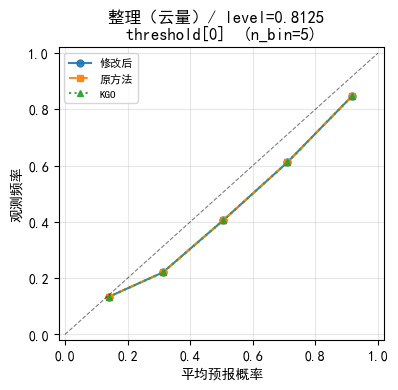

In [14]:
mig_map = reliability_tables_to_map(mig_cloud_list, from_meb=True)
kgo_map = reliability_tables_to_map(kgo_cloud_list, from_meb=False)
orig_map = (
    reliability_tables_to_map(orig_cloud_list, from_meb=False) if orig_cloud_list is not None else {}
)

summarize_level_maps("整理（云量）", mig_map, orig_map, kgo_map)

# level=0 合并后可能只剩 1 箱；选箱数最多的阈值作图
lev_plot = max(kgo_map, key=lambda lev: kgo_map[lev].shape[-1])
orig_arr0 = orig_map.get(lev_plot, kgo_map[lev_plot])
print(
    f"绘图阈值 level={lev_plot}, n_bin={kgo_map[lev_plot].shape[-1]}"
    + ("（原方法结果缺失，中线暂用 KGO）" if lev_plot not in orig_map else "")
)
plot_reliability_diagrams(
    mig_map[lev_plot][np.newaxis, ...],
    orig_arr0[np.newaxis, ...],
    kgo_map[lev_plot][np.newaxis, ...],
    f"整理（云量）/ level={lev_plot}",
)


## 6. ApplyReliabilityCalibration

用例目录：`test_data/apply-reliability-calibration/basic/`

### 6.1 输入读取

In [15]:
APPLY_DIR = DATA_DIR / "apply-reliability-calibration" / "basic"
APPLY_CLI = APPLY_DIR / "cli_input"

apply_fc_in = xr.open_dataarray(APPLY_CLI / "forecast.nc")
apply_tab_in = xr.open_dataset(APPLY_CLI / "collapsed_table.nc")
print("apply forecast", apply_fc_in.dims, dict(apply_fc_in.sizes))


apply forecast ('member', 'level', 'time', 'dtime', 'lat', 'lon') {'member': 1, 'level': 2, 'time': 1, 'dtime': 1, 'lat': 49, 'lon': 53}


### 6.2 插件方法调用


In [16]:
# 修改后插件方法调用
mig_apply = ApplyReliabilityCalibration().process(apply_fc_in, apply_tab_in)

In [17]:
# 原方法调用
orig_apply = OrigApply().process(
    iris.load_cube(str(APPLY_DIR / "forecast.nc")),
    iris.load_cube(str(APPLY_DIR / "collapsed_table.nc")),
)


### 6.3 数值对比与绘图对比


订正应用: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
订正应用: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
订正应用: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


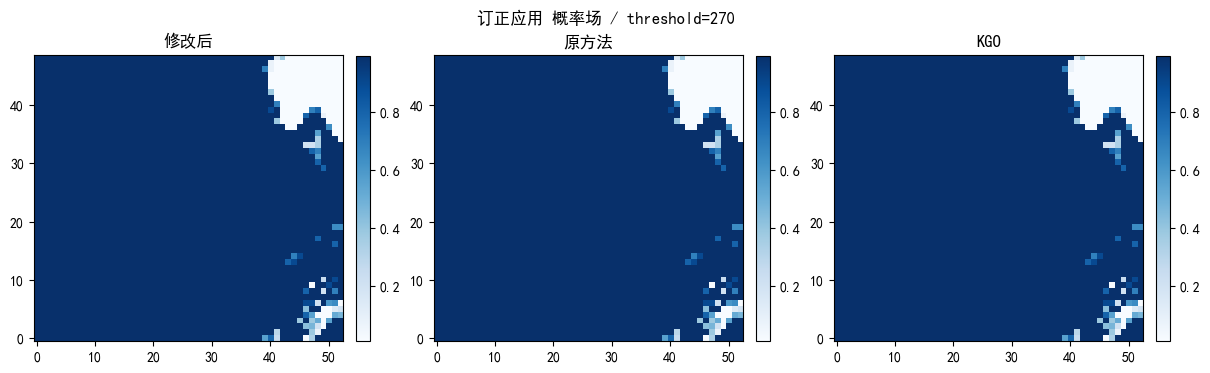

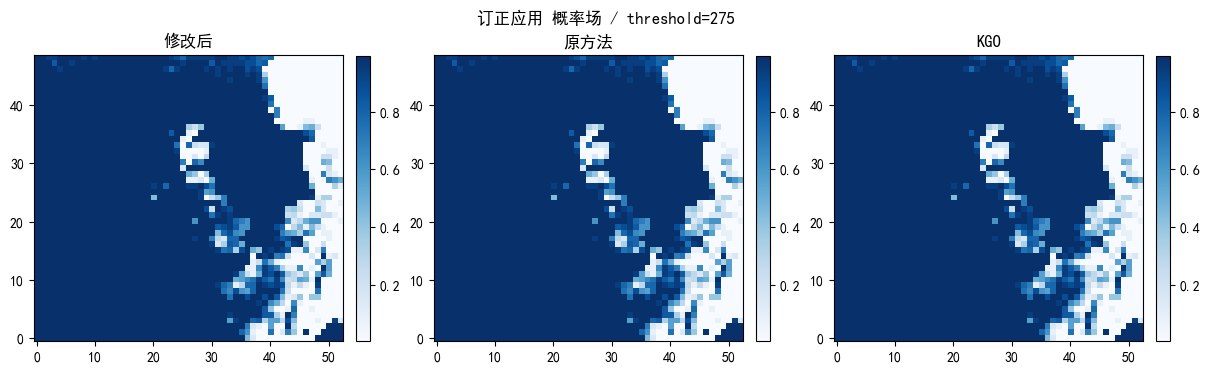

In [18]:
kgo_apply = iris.load_cube(str(APPLY_DIR / "kgo.nc"))

mig_arr = np.asarray(mig_apply.values[0, :, 0, 0, :, :], dtype=np.float32)
orig_arr = np.asarray(orig_apply.data, dtype=np.float32)
kgo_arr = np.asarray(kgo_apply.data, dtype=np.float32)

summarize_triple("订正应用", mig_arr, orig_arr, kgo_arr)

for ithr, thr in enumerate(apply_fc_in["level"].values):
    plot_triple_fields(
        mig_arr[ithr],
        orig_arr[ithr],
        kgo_arr[ithr],
        title=f"订正应用 概率场 / threshold={float(thr):.4g}",
        cmap="Blues",
    )


## 7. CLI 示例对照

- **修改后 CLI**：导入 `probability_reliability_correction.cli.prb_*` 的 `process`，读写各用例 `cli_input/` → `cli_output/`
- **原方法 CLI**：`improver_cli.main("improver", "<command>", ...)`，读取用例目录下 Iris 源
- **KGO**：官方预期输出

Construct 原版 CLI 直接使用已拼接的多时效 `forecast.nc` / `truth.nc`（不再在 Notebook 内拼接）。


### 7.1 Construct CLI


In [19]:
CONSTRUCT_OUT = CONSTRUCT_DIR / "cli_output"
CONSTRUCT_OUT.mkdir(parents=True, exist_ok=True)

# 修改后 CLI
mig_cli_construct = construct_cli_process(
    CONSTRUCT_CLI / "forecast.nc",
    CONSTRUCT_CLI / "truth.nc",
    n_probability_bins=5,
    output_path=CONSTRUCT_OUT / "mig_cli_reliability_table.nc",
)
print("修改后 Construct CLI ->", CONSTRUCT_OUT / "mig_cli_reliability_table.nc")

修改后 Construct CLI -> D:\workspace\improver\probability_reliability_correction\test_data\construct-reliability-tables\basic\cli_output\mig_cli_reliability_table.nc


In [20]:
# 原方法 CLI：多时效 Iris 源
orig_cli_construct_nc = CONSTRUCT_OUT / "orig_cli_reliability_table.nc"
ensure_path_removed(orig_cli_construct_nc)
improver_cli.main(
    "improver",
    "construct-reliability-tables",
    str(CONSTRUCT_DIR / "forecast.nc"),
    str(CONSTRUCT_DIR / "truth.nc"),
    "--truth-attribute",
    "mosg__model_configuration=uk_det",
    "--output",
    str(orig_cli_construct_nc),
    verbose=True,
)

Run-time: 1.121995700057596s; improver construct-reliability-tables 'D:\workspace\improver\probability_reliability_correction\test_data\construct-reliability-tables\basic\forecast.nc' 'D:\workspace\improver\probability_reliability_correction\test_data\construct-reliability-tables\basic\truth.nc' --truth-attribute mosg__model_configuration=uk_det --output 'D:\workspace\improver\probability_reliability_correction\test_data\construct-reliability-tables\basic\cli_output\orig_cli_reliability_table.nc'


建表 CLI: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
建表 CLI: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
建表 CLI: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


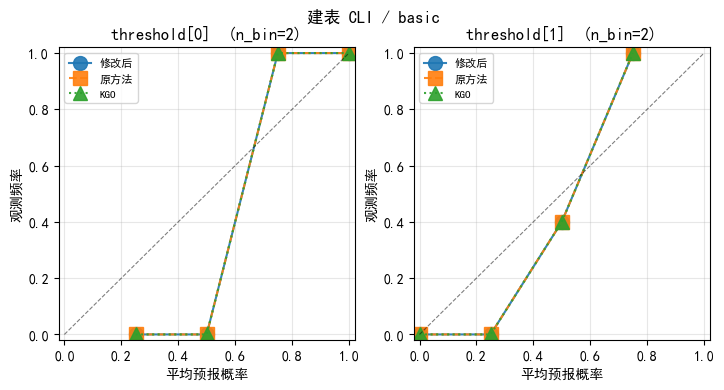

In [21]:
orig_cli_construct = iris.load_cube(str(orig_cli_construct_nc))
kgo_construct = iris.load_cube(str(CONSTRUCT_DIR / "kgo_without_single_value_bins.nc"))

mig_arr = meb_table_to_iris_layout(mig_cli_construct)
orig_arr = iris_table_data(orig_cli_construct)
kgo_arr = iris_table_data(kgo_construct)
summarize_triple("建表 CLI", mig_arr, orig_arr, kgo_arr)
plot_reliability_diagrams(mig_arr, orig_arr, kgo_arr, "建表 CLI / basic")


### 7.2 Aggregate CLI（空间折叠）


In [22]:
AGG_OUT = AGG_DIR / "cli_output"
AGG_OUT.mkdir(parents=True, exist_ok=True)

# 修改后 CLI
mig_cli_agg = aggregate_cli_process(
    [AGG_CLI / "reliability_table.nc"],
    coordinates=["lat", "lon"],
    output_path=AGG_OUT / "mig_cli_collapsed.nc",
)
print("修改后 Aggregate CLI ->", AGG_OUT / "mig_cli_collapsed.nc")

修改后 Aggregate CLI -> D:\workspace\improver\probability_reliability_correction\test_data\aggregate-reliability-tables\basic\cli_output\mig_cli_collapsed.nc


In [23]:
orig_cli_agg_nc = AGG_OUT / "orig_cli_collapsed.nc"
ensure_path_removed(orig_cli_agg_nc)
# 原方法 CLI
improver_cli.main(
    "improver",
    "aggregate-reliability-tables",
    str(AGG_DIR / "reliability_table.nc"),
    "--coordinates",
    "latitude,longitude",
    "--output",
    str(orig_cli_agg_nc),
    verbose=True,
)


Run-time: 0.047803400084376335s; improver aggregate-reliability-tables 'D:\workspace\improver\probability_reliability_correction\test_data\aggregate-reliability-tables\basic\reliability_table.nc' --coordinates latitude,longitude --output 'D:\workspace\improver\probability_reliability_correction\test_data\aggregate-reliability-tables\basic\cli_output\orig_cli_collapsed.nc'


聚合 CLI: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
聚合 CLI: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
聚合 CLI: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


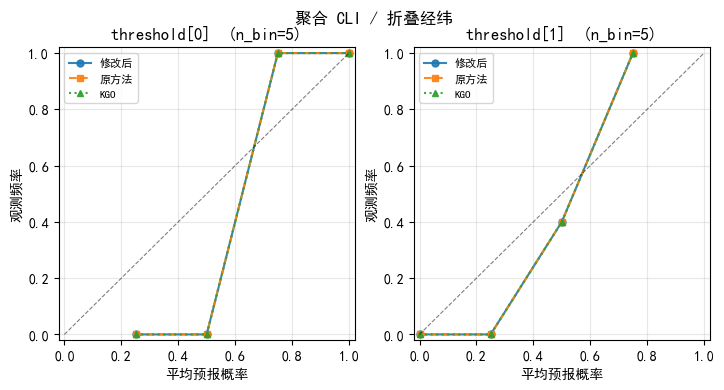

In [24]:
orig_cli_agg = iris.load_cube(str(orig_cli_agg_nc))
kgo_agg = iris_table_data(iris.load_cube(str(AGG_DIR / "collapse_lat_lon_kgo.nc")))

mig_arr = meb_table_to_iris_layout(mig_cli_agg)[:, :, :, 0, 0]
orig_arr = iris_table_data(orig_cli_agg)
summarize_triple("聚合 CLI", mig_arr, orig_arr, kgo_agg)
plot_reliability_diagrams(mig_arr, orig_arr, kgo_agg, "聚合 CLI / 折叠经纬")


### 7.3 Manipulate CLI（云量表，`minimum_forecast_count=300`）

原版 Manipulate CLI 在 Iris 3.x 下需先打 `probability_bin.var_name` 兼容补丁（与 §5 相同）。


In [25]:
MAN_OUT = MAN_DIR / "cli_output"
MAN_OUT.mkdir(parents=True, exist_ok=True)
mig_man_dir = MAN_OUT / "mig_cli_cloud_min300"
ensure_path_removed(mig_man_dir)
mig_man_dir.mkdir(parents=True, exist_ok=True)

# 修改后 CLI
mig_cli_man = manipulate_cli_process(
    MAN_CLI / "reliability_table_cloud.nc",
    minimum_forecast_count=300,
    output_path=mig_man_dir,
)
print("修改后 Manipulate CLI ->", mig_man_dir, "n=", len(mig_cli_man))

已写出 17 个阈值表 -> D:\workspace\improver\probability_reliability_correction\test_data\manipulate-reliability-table\basic\cli_output\mig_cli_cloud_min300
修改后 Manipulate CLI -> D:\workspace\improver\probability_reliability_correction\test_data\manipulate-reliability-table\basic\cli_output\mig_cli_cloud_min300 n= 17


In [26]:
# 为Manipulate 方法打 Iris 3.x 的 var_name 补丁
patch_orig_manipulate_for_iris()
orig_cli_man_nc = MAN_OUT / "orig_cli_cloud_min300.nc"
ensure_path_removed(orig_cli_man_nc)
# 原方法 CLI
improver_cli.main(
    "improver",
    "manipulate-reliability-table",
    str(MAN_DIR / "reliability_table_cloud.nc"),
    "--minimum-forecast-count",
    "300",
    "--output",
    str(orig_cli_man_nc),
    verbose=True,
)

Run-time: 0.29001270001754165s; improver manipulate-reliability-table 'D:\workspace\improver\probability_reliability_correction\test_data\manipulate-reliability-table\basic\reliability_table_cloud.nc' --minimum-forecast-count 300 --output 'D:\workspace\improver\probability_reliability_correction\test_data\manipulate-reliability-table\basic\cli_output\orig_cli_cloud_min300.nc'


整理 CLI: 修改后 ~ KGO: 一致 17/17, max(maxabs)=0.0, 缺侧=0, shape不一致=0
整理 CLI: 原方法 ~ KGO: 一致 17/17, max(maxabs)=0.0, 缺侧=0, shape不一致=0
整理 CLI: 修改后 ~ 原方法: 一致 17/17, max(maxabs)=0.0, 缺侧=0, shape不一致=0
整理 CLI: 阈值数=17, 各阈值箱数={0.0: 1, 0.0625: 3, 0.125: 4, 0.1875: 5, 0.25: 5, 0.3125: 4, 0.375: 4, 0.4375: 4, 0.5: 4, 0.5625: 5, 0.625: 5, 0.6875: 5, 0.75: 5, 0.8125: 5, 0.875: 5, 0.9375: 5, 1.0: 5}


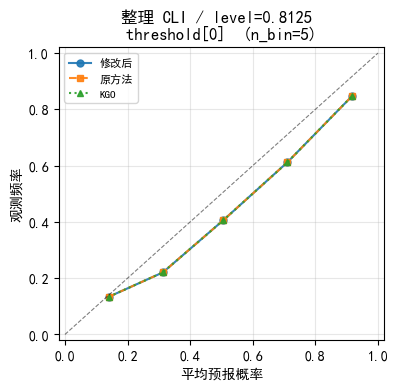

In [27]:
orig_cli_man = iris.load(str(orig_cli_man_nc))
kgo_man = iris.load(str(MAN_DIR / "kgo_300_min_count.nc"))


mig_map = reliability_tables_to_map(mig_cli_man, from_meb=True)
orig_map = reliability_tables_to_map(orig_cli_man, from_meb=False)
kgo_map = reliability_tables_to_map(kgo_man, from_meb=False)
summarize_level_maps("整理 CLI", mig_map, orig_map, kgo_map)

lev_plot = max(kgo_map, key=lambda lev: kgo_map[lev].shape[-1])
plot_reliability_diagrams(
    mig_map[lev_plot][np.newaxis, ...],
    orig_map[lev_plot][np.newaxis, ...],
    kgo_map[lev_plot][np.newaxis, ...],
    f"整理 CLI / level={lev_plot}",
)


### 7.4 Apply CLI


In [28]:
APPLY_OUT = APPLY_DIR / "cli_output"
APPLY_OUT.mkdir(parents=True, exist_ok=True)

# 修改后 CLI
mig_cli_apply = apply_cli_process(
    APPLY_CLI / "forecast.nc",
    [APPLY_CLI / "collapsed_table.nc"],
    output_path=APPLY_OUT / "mig_cli_calibrated.nc",
)
print("修改后 Apply CLI ->", APPLY_OUT / "mig_cli_calibrated.nc")

修改后 Apply CLI -> D:\workspace\improver\probability_reliability_correction\test_data\apply-reliability-calibration\basic\cli_output\mig_cli_calibrated.nc


In [29]:
orig_cli_apply_nc = APPLY_OUT / "orig_cli_calibrated.nc"
ensure_path_removed(orig_cli_apply_nc)
# 原方法 CLI
improver_cli.main(
    "improver",
    "apply-reliability-calibration",
    str(APPLY_DIR / "forecast.nc"),
    str(APPLY_DIR / "collapsed_table.nc"),
    "--output",
    str(orig_cli_apply_nc),
    verbose=True,
)

Run-time: 0.0901190999429673s; improver apply-reliability-calibration 'D:\workspace\improver\probability_reliability_correction\test_data\apply-reliability-calibration\basic\forecast.nc' 'D:\workspace\improver\probability_reliability_correction\test_data\apply-reliability-calibration\basic\collapsed_table.nc' --output 'D:\workspace\improver\probability_reliability_correction\test_data\apply-reliability-calibration\basic\cli_output\orig_cli_calibrated.nc'


订正 CLI: 修改后 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
订正 CLI: 原方法 ~ KGO: allclose=True maxabs=0.0 meanabs=0.0
订正 CLI: 修改后 ~ 原方法: allclose=True maxabs=0.0 meanabs=0.0


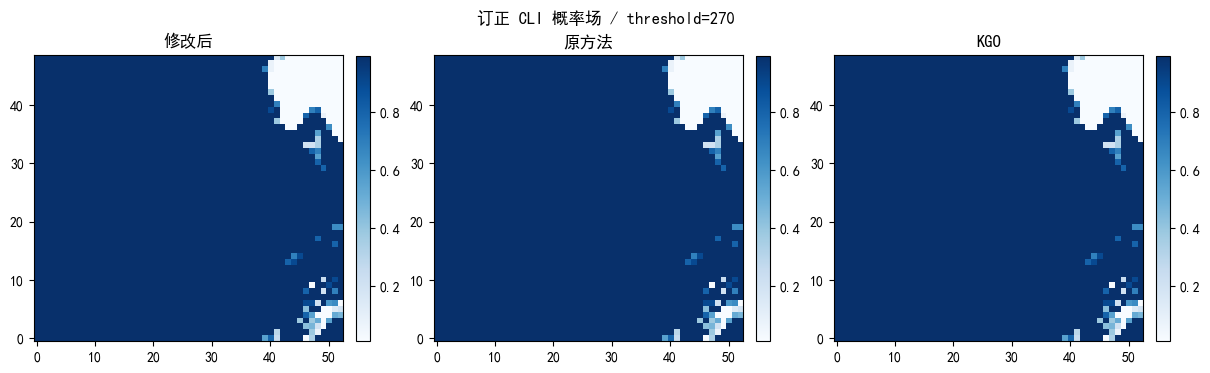

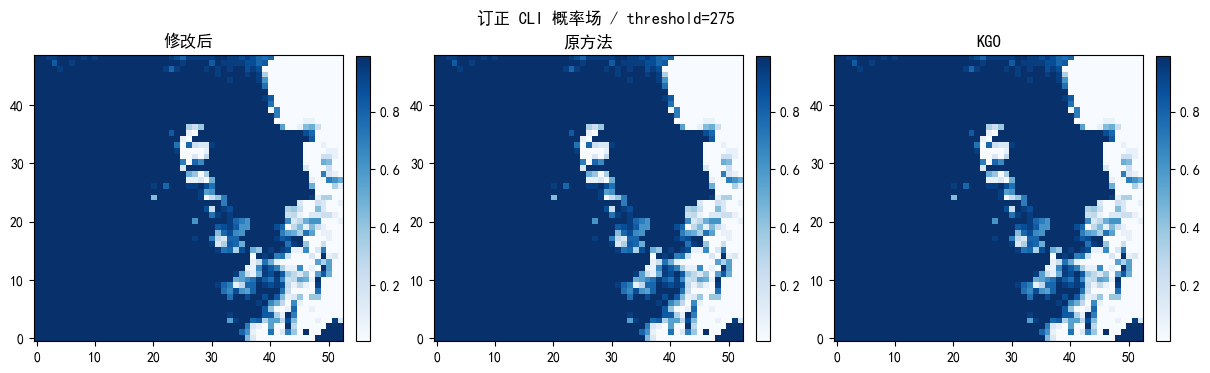

In [30]:
orig_cli_apply = iris.load_cube(str(orig_cli_apply_nc))
kgo_apply = iris.load_cube(str(APPLY_DIR / "kgo.nc"))

mig_arr = np.asarray(mig_cli_apply.values[0, :, 0, 0, :, :], dtype=np.float32)
orig_arr = np.asarray(orig_cli_apply.data, dtype=np.float32)
kgo_arr = np.asarray(kgo_apply.data, dtype=np.float32)
summarize_triple("订正 CLI", mig_arr, orig_arr, kgo_arr)

for ithr, thr in enumerate(np.asarray(mig_cli_apply["level"].values)):
    plot_triple_fields(
        mig_arr[ithr],
        orig_arr[ithr],
        kgo_arr[ithr],
        title=f"订正 CLI 概率场 / threshold={float(thr):.4g}",
        cmap="Blues",
    )
